#My temporary idea: pipeline overview

1. Data understanding, EDA
2. Test relationships and construct relationshp graph
3. Features engenieering, turn graph into ML input
4. ML model
5. Cross wafer validation
6. Evaluation and interpretation

First we're loading up the data and organizing the files in 4 csv:
- 1 csv with the threshold (only two rows)
- 3 csv, one for each wafer

In [2]:
import pandas as pd


print(" STEP 1 — EDA STARTING ")

# 0. LOAD DATA
print("Loading dataset...")

# Method 1: Direct full path
df = pd.read_csv("/Users/geotech/Desktop/Master_AI/Master/AML/Data_Analysis/data.csv")

# Method 2: Using raw string (useful for Windows paths)
# df = pd.read_csv(r"/Users/geotech/Desktop/Master_AI/Master/AML/Data_Analysis/data.csv")


print(f"Dataset shape: {df.shape}")
print("First rows preview:")
print(df.head(), "\n")

 STEP 1 — EDA STARTING 
Loading dataset...
Dataset shape: (78461, 588)
First rows preview:
   Source Lot      Lot         Wafer  rework_flag  \
0         NaN      NaN           NaN          NaN   
1         NaN      NaN           NaN          NaN   
2         NaN  DMKY8.1  DMKY801-C_C2          0.0   
3         NaN  DMKY8.1  DMKY801-C_C2          0.0   
4         NaN  DMKY8.1  DMKY801-C_C2          0.0   

                               Program  temperature       subid  site  die_x  \
0                                  NaN          NaN         NaN   NaN    NaN   
1                                  NaN          NaN         NaN   NaN    NaN   
2  NCA9555DRB_NCA9555/B1T/8X_W1_N_wpar         25.0  nbvg36n008   4.0    6.0   
3  NCA9555DRB_NCA9555/B1T/8X_W1_N_wpar         25.0  nbvg36n008   4.0    6.0   
4  NCA9555DRB_NCA9555/B1T/8X_W1_N_wpar         25.0  nbvg36n008   4.0    6.0   

   die_y  ...  NCA_pullup:I2C_NACK:300.000 mV (7)  \
0    NaN  ...                             -40.000   
1  

In [3]:
print("All column names:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:3}. {col}")

# Also show count
print(f"Total columns: {len(df.columns)}")

All column names:
  1. Source Lot
  2. Lot
  3. Wafer
  4. rework_flag
  5. Program
  6. temperature
  7. subid
  8. site
  9. die_x
 10. die_y
 11. device_nr
 12. rom_code
 13. hardbin
 14. lib_info
 15. BinName
 16. BinState
 17. tb_cont_all:CONT_VCC:-5.000 mA
 18. tb_cont_all:CONT_N:-5.000 mA
 19. tb_cont_all:CONT_N:-5.000 mA (2)
 20. tb_cont_all:CONT_N:-5.000 mA (3)
 21. tb_cont_all:CONT_N:-5.000 mA (4)
 22. tb_cont_all:CONT_N:-5.000 mA (5)
 23. tb_cont_all:CONT_N:-5.000 mA (6)
 24. tb_cont_all:CONT_N:-5.000 mA (7)
 25. tb_cont_all:CONT_N:-5.000 mA (8)
 26. tb_cont_all:CONT_N:-5.000 mA (9)
 27. tb_cont_all:CONT_N:-5.000 mA (10)
 28. tb_cont_all:CONT_N:-5.000 mA (11)
 29. tb_cont_all:CONT_N:-5.000 mA (12)
 30. tb_cont_all:CONT_N:-5.000 mA (13)
 31. tb_cont_all:CONT_N:-5.000 mA (14)
 32. tb_cont_all:CONT_N:-5.000 mA (15)
 33. tb_cont_all:CONT_N:-5.000 mA (16)
 34. tb_cont_all:CONT_N:-5.000 mA (17)
 35. tb_cont_all:CONT_N:-5.000 mA (18)
 36. tb_cont_all:CONT_N:-5.000 mA (19)
 37. tb_c

In [4]:
# 1. IDENTIFY WAFERS

print("Splitting by wafer...")

if "Wafer" in df.columns:
    wafers = df["Wafer"].unique()
    wafer_groups = {w: df[df["Wafer"] == w].copy() for w in wafers}
else:
    raise ValueError("No 'Wafer' column found. Please check dataset structure.")

print(f"Found wafers: {list(wafers)}")

Splitting by wafer...
Found wafers: [nan, 'DMKY801-C_C2', 'DMKY801-C_C3', 'DMKY801-C_C7', 'DMKY801-C_C5', 'DMKY801-C_C4', 'DMKY801-C_C8', 'DMKY801-C_C9', 'DMKY806-H_C10', 'DMKY806-H_C1', 'DMKY801-C_C6', 'DMKY806-H_C3', 'DMKY806-H_C4', 'DMKY806-H_C2', 'DMKY806-H_C7', 'DMKY806-H_C5', 'DMKY806-H_C9', 'DMKY812-C_C1', 'DMKY806-H_C8', 'DMKY812-C_C4', 'DMKY812-C_C7', 'DMKY812-C_C9', 'DMKY801-C_C1', 'DMKY801-C_C10', 'DMKY806-H_C6', 'DMKY812-C_C3', 'DMKY812-C_C2', 'DMKY812-C_C10', 'DMKY812-C_C5', 'DMKY812-C_C6', 'DMKY812-C_C8']


In [5]:
# 1. EXTRACT THRESHOLD LINES
print("Extracting threshold lines...")

# Extract first 2 lines as thresholds
threshold_lines = df.iloc[:2].copy()
threshold_lines.to_csv("thresholds.csv", index=False)
print(f"Saved first 2 lines (thresholds) to 'thresholds.csv'")
print(f"Threshold lines shape: {threshold_lines.shape}\n")

# Remove threshold lines from main dataframe
df_data = df.iloc[2:].reset_index(drop=True)
print(f"Data after removing thresholds: {df_data.shape}")


Extracting threshold lines...
Saved first 2 lines (thresholds) to 'thresholds.csv'
Threshold lines shape: (2, 588)

Data after removing thresholds: (78459, 588)


In [ ]:
# SIMPLIFIED EXTRACTION & GROUPING

print("Extracting and grouping by wafer number...")

# Extract wafer number using simple string slicing
# The pattern is always 'DMKYXXX-' where XXX is the wafer number
df_data['Wafer_Number'] = df_data['Wafer'].str.extract(r'DMKY(\d{3})-')

# Remove rows without valid wafer number (should be none if all follow pattern)
df_data_clean = df_data.dropna(subset=['Wafer_Number']).copy()

# Group by wafer number and save in one go
for wafer_num, group in df_data_clean.groupby('Wafer_Number'):
    filename = f"wafer_{wafer_num}.csv"
    group.drop('Wafer_Number', axis=1).to_csv(filename, index=False)
    print(f"  ✓ Wafer {wafer_num}: {len(group)} rows → '{filename}'")

print(f"\n✓ Created files for wafers: {df_data_clean['Wafer_Number'].unique().tolist()}")

In [ ]:
# Check shapes of all wafer CSV files
for wafer_num in ['801', '806', '812']:
    filename = f"wafer_{wafer_num}.csv"
    try:
        df = pd.read_csv(filename)
        print(f"{filename}: {df.shape[0]} rows, {df.shape[1]} columns")
    except FileNotFoundError:
        print(f"{filename}: NOT FOUND")

Since I dont wanna re-make the files everytime and i already have them saved from doing this locally, i will just load up the csv i have stored on my device

In [7]:
print(" STEP 1 — LOADING EXISTING FILES ")

# Define the folder path
folder_path = "/Users/geotech/Desktop/Master_AI/Master/AML/Data_Analysis"

# Load threshold file
thresholds = pd.read_csv(f"{folder_path}/thresholds.csv")
print(f"✓ Loaded thresholds.csv: {thresholds.shape[0]} rows, {thresholds.shape[1]} columns")

# Load the 3 wafer files
wafer_801 = pd.read_csv(f"{folder_path}/wafer_801.csv")
wafer_806 = pd.read_csv(f"{folder_path}/wafer_806.csv")
wafer_812 = pd.read_csv(f"{folder_path}/wafer_812.csv")

print(f"✓ Loaded wafer_801.csv: {wafer_801.shape[0]} rows, {wafer_801.shape[1]} columns")
print(f"✓ Loaded wafer_806.csv: {wafer_806.shape[0]} rows, {wafer_806.shape[1]} columns")
print(f"✓ Loaded wafer_812.csv: {wafer_812.shape[0]} rows, {wafer_812.shape[1]} columns")

# Optional: Preview first few rows
print("\nThresholds preview:")
print(thresholds.head(), "\n")

print("Wafer 801 preview:")
print(wafer_801.head())

 STEP 1 — LOADING EXISTING FILES 
The history saving thread hit an unexpected error (OperationalError('unable to open database file')).History will not be written to the database.
✓ Loaded thresholds.csv: 2 rows, 588 columns
✓ Loaded wafer_801.csv: 26149 rows, 588 columns
✓ Loaded wafer_806.csv: 26155 rows, 588 columns
✓ Loaded wafer_812.csv: 26155 rows, 588 columns

Thresholds preview:
   Source Lot  Lot  Wafer  rework_flag  Program  temperature  subid  site  \
0         NaN  NaN    NaN          NaN      NaN          NaN    NaN   NaN   
1         NaN  NaN    NaN          NaN      NaN          NaN    NaN   NaN   

   die_x  die_y  ...  NCA_pullup:I2C_NACK:300.000 mV (7)  \
0    NaN    NaN  ...                               -40.0   
1    NaN    NaN  ...                                40.0   

   NCA_pullup:I2C_NACK:300.000 mV (8)  NCA_pullup:I2C_NACK:300.000 mV (9)  \
0                               -40.0                               -40.0   
1                                40.0      


Processing Wafer 801...
  ⚠ Not enough disk space OR saving disabled → showing summary

Top correlations (absolute):
tb_VOL:VOL_3v:8.000 mA (11)   tb_VOL:VOL_2v3:8.000 mA (12)    0.999992
tb_VOL:VOL_2v3:8.000 mA (12)  tb_VOL:VOL_3v:8.000 mA (11)     0.999992
tb_VOL:VOL_3v:8.000 mA (16)   tb_VOL:VOL_2v3:8.000 mA (6)     0.999992
tb_VOL:VOL_2v3:8.000 mA (6)   tb_VOL:VOL_3v:8.000 mA (16)     0.999992
tb_VOL:VOL_3v:8.000 mA (10)   tb_VOL:VOL_2v3:8.000 mA (7)     0.999991
tb_VOL:VOL_2v3:8.000 mA (7)   tb_VOL:VOL_3v:8.000 mA (10)     0.999991
tb_VOL:VOL_2v3:8.000 mA (8)   tb_VOL:VOL_3v:8.000 mA (9)      0.999991
tb_VOL:VOL_3v:8.000 mA (9)    tb_VOL:VOL_2v3:8.000 mA (8)     0.999991
tb_VOL:VOL_2v3:8.000 mA (2)   tb_VOL:VOL_3v:8.000 mA (5)      0.999990
tb_VOL:VOL_3v:8.000 mA (5)    tb_VOL:VOL_2v3:8.000 mA (2)     0.999990
dtype: float64


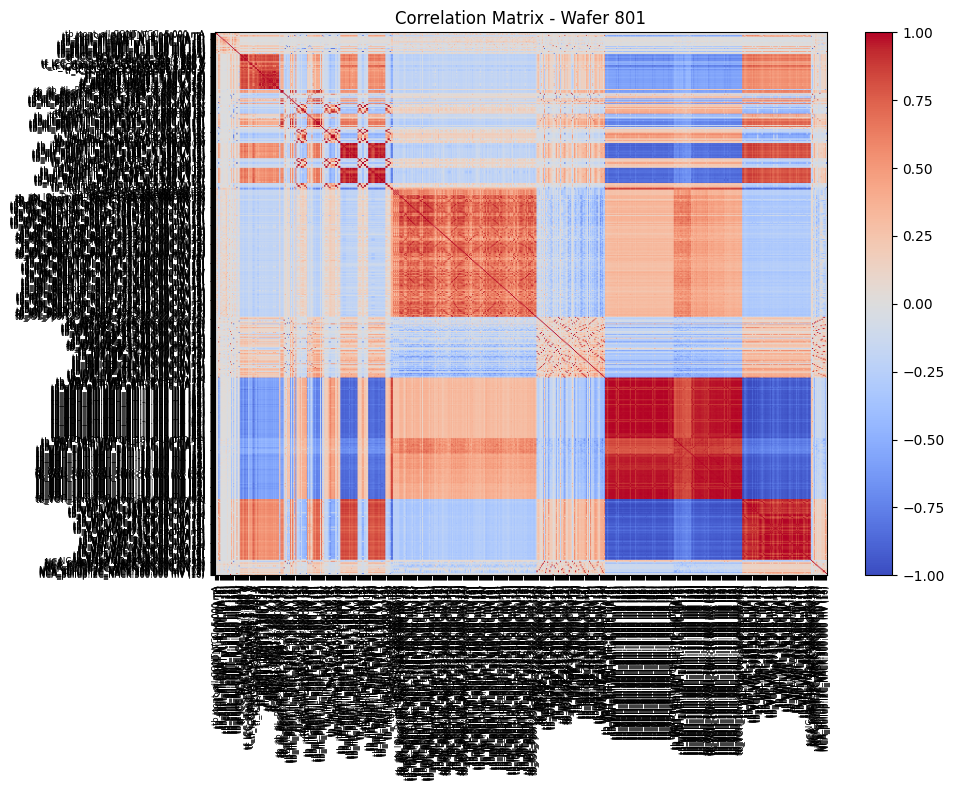


Processing Wafer 806...
  ⚠ Not enough disk space OR saving disabled → showing summary

Top correlations (absolute):
tb_IOZ:IOZ_1v65:300.000 mV (14)      NCA_pullup:I2C_NACK:300.000 mV (8)     0.999851
NCA_pullup:I2C_NACK:300.000 mV (8)   tb_IOZ:IOZ_1v65:300.000 mV (14)        0.999851
tb_iinH:iinH_1v65_vi_0:0.000 uV (4)  tb_iinL:iinL_1v65_vi_0:0.000 uV        0.999842
tb_iinL:iinL_1v65_vi_0:0.000 uV      tb_iinH:iinH_1v65_vi_0:0.000 uV (4)    0.999842
tb_VOH_8m:VOH_8m:-8.000 mA (40)      tb_VOH_8m:VOH_8m:-8.000 mA (20)        0.999737
tb_VOH_8m:VOH_8m:-8.000 mA (20)      tb_VOH_8m:VOH_8m:-8.000 mA (40)        0.999737
tb_VOH_8m:VOH_8m:-8.000 mA (27)      tb_VOH_8m:VOH_8m:-8.000 mA (43)        0.999733
tb_VOH_8m:VOH_8m:-8.000 mA (43)      tb_VOH_8m:VOH_8m:-8.000 mA (27)        0.999733
tb_IOZ:IOZ_1v65:300.000 mV (3)       NCA_pullup:I2C_NACK:300.000 mV (11)    0.999732
NCA_pullup:I2C_NACK:300.000 mV (11)  tb_IOZ:IOZ_1v65:300.000 mV (3)         0.999732
dtype: float64


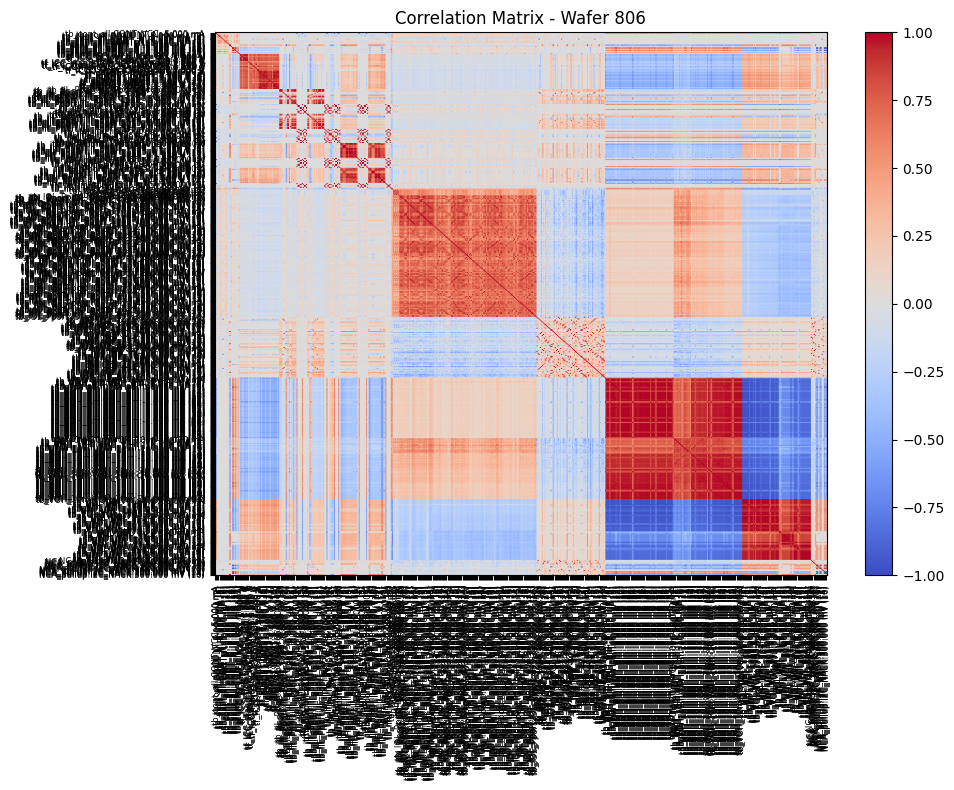


Processing Wafer 812...
  ⚠ Not enough disk space OR saving disabled → showing summary

Top correlations (absolute):
tb_VOL:VOL_2v3:8.000 mA (7)   tb_VOL:VOL_3v:8.000 mA (10)     0.999992
tb_VOL:VOL_3v:8.000 mA (10)   tb_VOL:VOL_2v3:8.000 mA (7)     0.999992
tb_VOL:VOL_3v:8.000 mA (16)   tb_VOL:VOL_2v3:8.000 mA (6)     0.999992
tb_VOL:VOL_2v3:8.000 mA (6)   tb_VOL:VOL_3v:8.000 mA (16)     0.999992
tb_VOL:VOL_3v:8.000 mA (13)   tb_VOL:VOL_2v3:8.000 mA (3)     0.999991
tb_VOL:VOL_2v3:8.000 mA (3)   tb_VOL:VOL_3v:8.000 mA (13)     0.999991
tb_VOL:VOL_3v:8.000 mA (11)   tb_VOL:VOL_2v3:8.000 mA (12)    0.999991
tb_VOL:VOL_2v3:8.000 mA (12)  tb_VOL:VOL_3v:8.000 mA (11)     0.999991
tb_VOL:VOL_3v:8.000 mA (9)    tb_VOL:VOL_2v3:8.000 mA (8)     0.999986
tb_VOL:VOL_2v3:8.000 mA (8)   tb_VOL:VOL_3v:8.000 mA (9)      0.999986
dtype: float64


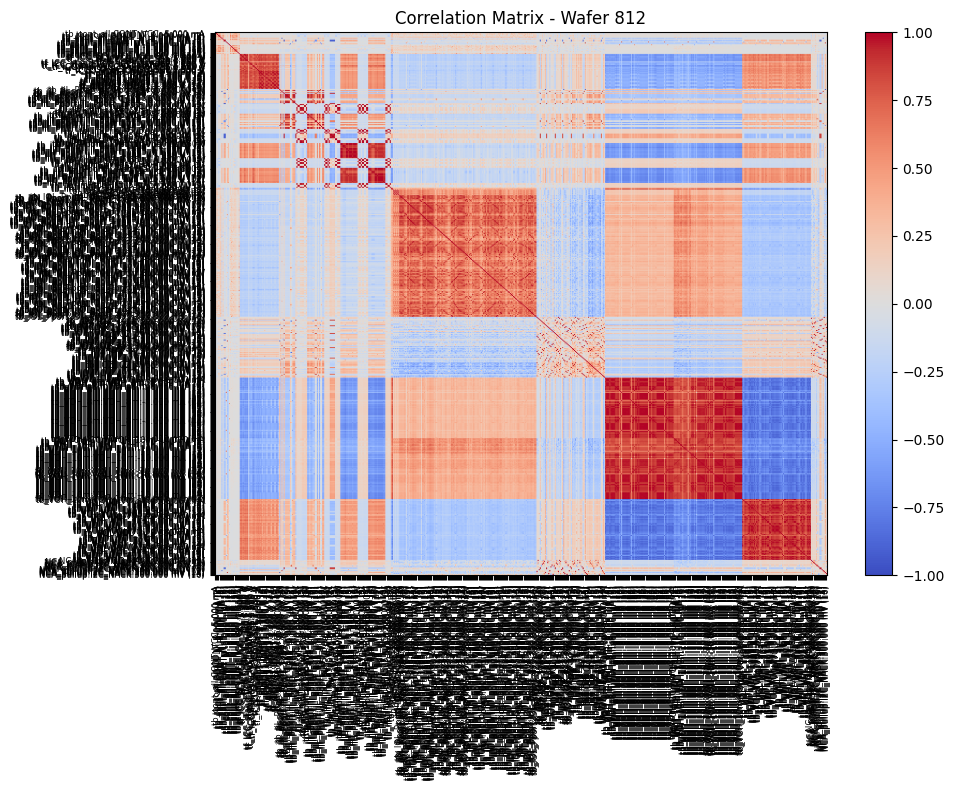


✓ Done processing all wafers


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import shutil

# Create output folder
output_dir = "correlation_results"
os.makedirs(output_dir, exist_ok=True)

# --- CONFIG ---
SAVE_RESULTS = True          # master switch
MIN_FREE_GB = 0.5            # minimum free space required

def has_enough_space(path, min_gb):
    total, used, free = shutil.disk_usage(path)
    return free / (1024**3) > min_gb

def clean_numeric(df):
    df = df.apply(pd.to_numeric, errors='coerce')

    # drop columns with too many NaNs
    df = df.loc[:, df.isna().mean() < 0.2]

    # drop constant columns (important for correlation stability)
    df = df.loc[:, df.nunique(dropna=True) > 1]

    return df

def plot_corr(corr, wafer_num):
    plt.figure(figsize=(10, 8))
    im = plt.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
    plt.colorbar(im)

    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90, fontsize=6)
    plt.yticks(range(len(corr.index)), corr.index, fontsize=6)

    plt.title(f"Correlation Matrix - Wafer {wafer_num}")
    plt.tight_layout()
    plt.show()

    return im


# Process wafers
for wafer_num, wafer_df in [('801', wafer_801), ('806', wafer_806), ('812', wafer_812)]:
    print(f"\nProcessing Wafer {wafer_num}...")

    meta_cols = [
        "Source Lot", "Lot", "Wafer", "rework_flag", "Program", "temperature",
        "subid", "site", "die_x", "die_y", "device_nr", "rom_code",
        "hardbin", "lib_info", "BinName", "BinState"
    ]
    meta_cols = [c for c in meta_cols if c in wafer_df.columns]
    test_cols = [c for c in wafer_df.columns if c not in meta_cols]

    df_tests = clean_numeric(wafer_df[test_cols])

    if df_tests.shape[1] < 2:
        print(f"  ⚠ Not enough valid test columns for wafer {wafer_num}")
        continue

    corr_matrix = df_tests.corr(method='pearson')

    # ---- MODE DECISION ----
    can_save = SAVE_RESULTS and has_enough_space(output_dir, MIN_FREE_GB)

    if can_save:
        csv_path = f"{output_dir}/correlation_wafer_{wafer_num}.csv"
        img_path = f"{output_dir}/correlation_wafer_{wafer_num}.png"

        corr_matrix.to_csv(csv_path)

        plt.figure(figsize=(10, 8))
        plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
        plt.colorbar()
        plt.title(f"Correlation Matrix - Wafer {wafer_num}")
        plt.savefig(img_path, dpi=120, bbox_inches='tight')
        plt.close()

        print(f"  ✓ Saved CSV + PNG for wafer {wafer_num}")

    else:
        print(f"  ⚠ Not enough disk space OR saving disabled → showing summary")

        # summary output instead of saving
        print("\nTop correlations (absolute):")

        corr_abs = corr_matrix.abs().unstack()
        corr_abs = corr_abs[corr_abs < 1].sort_values(ascending=False).head(10)

        print(corr_abs)

        # safer plotting (works better in notebooks than imshow alone)
        plot_corr(corr_matrix, wafer_num)

print("\n✓ Done processing all wafers")

Now we compute the convergence matrix: Think of each test as a “sensor” watching thousands of chips: the correlation matrix is just checking whether two sensors wiggle together across all those chips—if whenever test A is a bit high on a chip, test B is also a bit high, they get a strong positive correlation (close to 1); if one goes up while the other goes down, it’s negative; and if they behave independently, it’s near zero—so you’re not measuring failure yet, just whether tests behave like copies, cousins, or strangers across the same population.